# People Analytics — IBM HR Analytics Dataset (Real)
### Analise completa de Turnover, Performance e Engajamento

**Fonte:** IBM HR Analytics Employee Attrition & Performance  
**Link Kaggle:** https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset  
**Stack:** Python · Pandas · Scikit-learn · XGBoost · Matplotlib · Seaborn

| | |
|---|---|
| Colaboradores | 1.470 |
| Variaveis originais | 35 |
| Variaveis utilizadas | 31 (removidas 4 constantes) |
| Target | Attrition (Yes/No) |
| Modelo | XGBoost Classifier |
| ROC-AUC | 0.784 |


## 0. Imports e Configuracao

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, auc)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#F5F2EC',
    'axes.facecolor':   '#F5F2EC',
    'axes.grid':        True,
    'grid.color':       '#DDD8CE',
    'grid.linewidth':   0.6,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.spines.left': False,
    'axes.spines.bottom': True,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
    'figure.dpi':       120,
})

C = {
    'red':   '#C0392B',
    'amber': '#D4860A',
    'green': '#1A7A4A',
    'blue':  '#1B4F8A',
    'teal':  '#1A6B6B',
    'ink':   '#0E0F11',
    'ink2':  '#3A3D44',
    'ink3':  '#7A7F8A',
}
print("OK")


OK


## 1. Carregamento e Limpeza dos Dados

In [2]:
# Dataset IBM HR Analytics (Kaggle)
df = pd.read_csv('/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f"Shape original: {df.shape}")
print(f"\nColunas constantes (sem variacao):")
for col in df.columns:
    if df[col].nunique() == 1:
        print(f"  {col}: {df[col].unique()[0]}")

# Removendo colunas sem valor preditivo
df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], inplace=True)
print(f"\nShape apos limpeza: {df.shape}")


Shape original: (1470, 35)

Colunas constantes (sem variacao):
  EmployeeCount: 1
  Over18: Y
  StandardHours: 80

Shape apos limpeza: (1470, 31)


In [3]:
# Verificar valores nulos
print("Valores nulos por coluna:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("Nenhum valor nulo!" if df.isnull().sum().sum() == 0 else "")

# Estatisticas descritivas das variaveis numericas principais
print("\nEstatisticas descritivas:")
df[['Age','MonthlyIncome','YearsAtCompany','TotalWorkingYears',
    'JobSatisfaction','WorkLifeBalance']].describe().round(1)


Valores nulos por coluna:
Series([], dtype: int64)
Nenhum valor nulo!

Estatisticas descritivas:


,Age,MonthlyIncome,YearsAtCompany,TotalWorkingYears,JobSatisfaction,WorkLifeBalance
count,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0
mean,36.9,6502.9,7.0,11.3,2.7,2.8
std,9.1,4708.0,6.1,7.8,1.1,0.7
min,18.0,1009.0,0.0,0.0,1.0,1.0
25%,30.0,2911.0,3.0,6.0,2.0,2.0
50%,36.0,4919.0,5.0,10.0,3.0,3.0
75%,43.0,8379.0,9.0,15.0,4.0,3.0
max,60.0,19999.0,40.0,40.0,4.0,4.0


In [4]:
# Criando EngagementScore (score composto de engajamento)
df['EngagementScore'] = (
    df['JobSatisfaction'] +
    df['EnvironmentSatisfaction'] +
    df['RelationshipSatisfaction'] +
    df['WorkLifeBalance'] +
    df['JobInvolvement']
) / 5

print("Distribuicao do Attrition:")
print(df['Attrition'].value_counts())
print(f"\nTaxa de turnover: {df['Attrition'].eq('Yes').mean()*100:.1f}%")
print(f"EngagementScore medio: {df['EngagementScore'].mean():.2f}/4.0")
df.head()


Distribuicao do Attrition:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Taxa de turnover: 16.1%
EngagementScore medio: 2.73/4.0


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,EngagementScore
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,1,0,8,0,1,6,4,0,5,2.2
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,1,10,3,3,10,7,1,7,2.8
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,2,0,7,3,3,0,0,0,0,2.8
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,0,8,3,3,8,7,3,0,3.2
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,4,1,6,3,3,2,2,2,2,2.6


## 2. Analise Exploratoria (EDA)

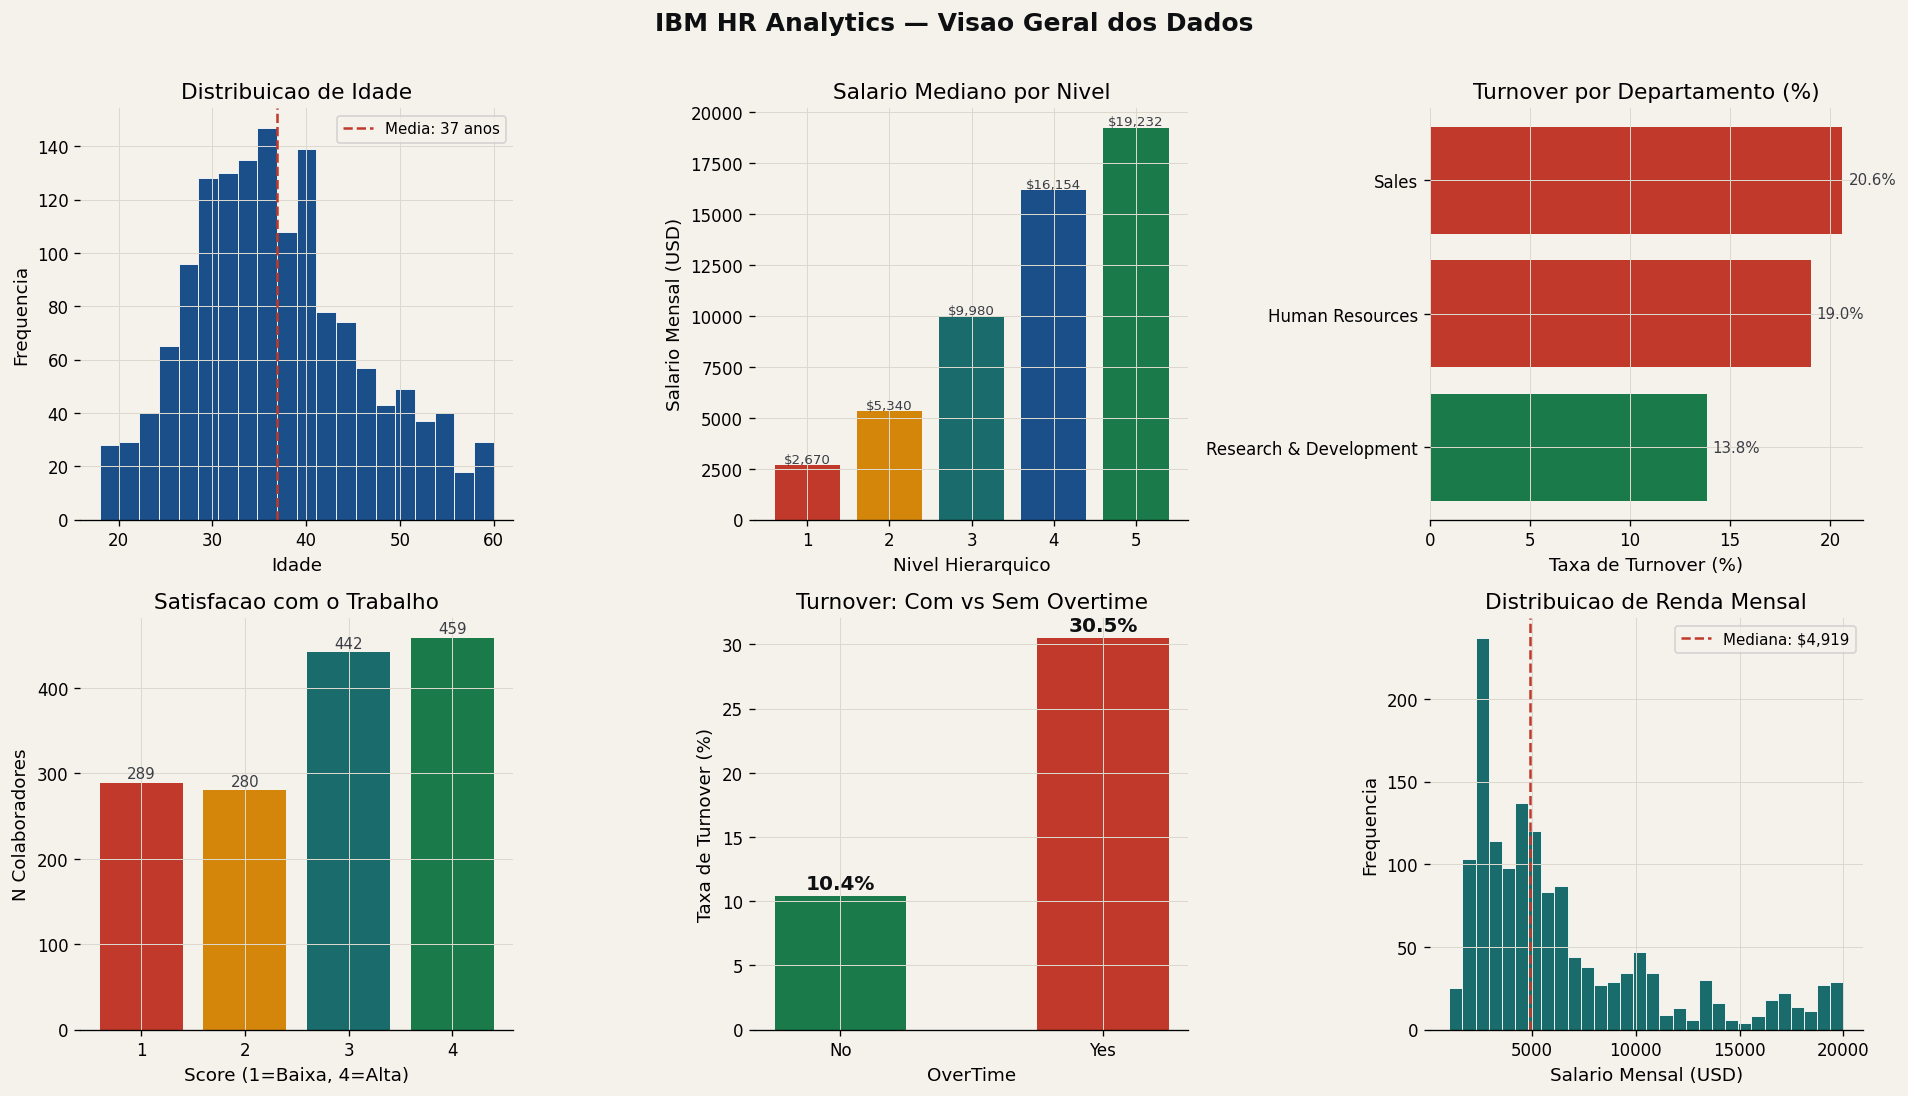

Figura salva: 01_eda_overview.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor('#F5F2EC')
fig.suptitle('IBM HR Analytics — Visao Geral dos Dados', fontsize=15,
             fontweight='bold', color=C['ink'], y=1.01)

# 1. Distribuicao de Idade
ax = axes[0,0]
ax.hist(df['Age'], bins=20, color=C['blue'], edgecolor='white', linewidth=0.5)
ax.axvline(df['Age'].mean(), color=C['red'], linestyle='--', linewidth=1.5,
           label=f"Media: {df['Age'].mean():.0f} anos")
ax.set_title('Distribuicao de Idade')
ax.set_xlabel('Idade'); ax.set_ylabel('Frequencia')
ax.legend(fontsize=9)

# 2. Salario por Nivel Hierarquico
ax = axes[0,1]
levels = sorted(df['JobLevel'].unique())
medians = [df[df['JobLevel']==l]['MonthlyIncome'].median() for l in levels]
lc = [C['red'],C['amber'],C['teal'],C['blue'],C['green']]
bars = ax.bar([str(l) for l in levels], medians, color=lc)
ax.set_title('Salario Mediano por Nivel')
ax.set_xlabel('Nivel Hierarquico'); ax.set_ylabel('Salario Mensal (USD)')
for bar, val in zip(bars, medians):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
            f'${val:,.0f}', ha='center', fontsize=8, color=C['ink2'])

# 3. Turnover por Departamento
ax = axes[0,2]
att_dept = df.groupby('Department')['Attrition'].apply(
    lambda x: (x=='Yes').mean()*100).sort_values(ascending=True)
dcols = [C['green'] if v<15 else C['amber'] if v<19 else C['red']
         for v in att_dept.values]
bars = ax.barh(att_dept.index, att_dept.values, color=dcols)
ax.set_title('Turnover por Departamento (%)')
ax.set_xlabel('Taxa de Turnover (%)')
for bar, val in zip(bars, att_dept.values):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, color=C['ink2'])

# 4. Satisfacao com o Trabalho
ax = axes[1,0]
sat = df['JobSatisfaction'].value_counts().sort_index()
ax.bar([str(i) for i in sat.index], sat.values,
       color=[C['red'],C['amber'],C['teal'],C['green']])
ax.set_title('Satisfacao com o Trabalho')
ax.set_xlabel('Score (1=Baixa, 4=Alta)'); ax.set_ylabel('N Colaboradores')
for i, (idx, val) in enumerate(sat.items()):
    ax.text(i, val+5, str(val), ha='center', fontsize=9, color=C['ink2'])

# 5. Overtime vs Turnover
ax = axes[1,1]
ot_att = df.groupby('OverTime')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
bars = ax.bar(ot_att.index, ot_att.values,
              color=[C['green'], C['red']], width=0.5)
ax.set_title('Turnover: Com vs Sem Overtime')
ax.set_xlabel('OverTime'); ax.set_ylabel('Taxa de Turnover (%)')
for bar, val in zip(bars, ot_att.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', fontsize=12,
            fontweight='bold', color=C['ink'])

# 6. Distribuicao de Renda
ax = axes[1,2]
ax.hist(df['MonthlyIncome'], bins=30, color=C['teal'],
        edgecolor='white', linewidth=0.5)
ax.axvline(df['MonthlyIncome'].median(), color=C['red'],
           linestyle='--', linewidth=1.5,
           label=f"Mediana: ${df['MonthlyIncome'].median():,.0f}")
ax.set_title('Distribuicao de Renda Mensal')
ax.set_xlabel('Salario Mensal (USD)'); ax.set_ylabel('Frequencia')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('01_eda_overview.png', dpi=150, bbox_inches='tight', facecolor='#F5F2EC')
plt.show()
print("Figura salva: 01_eda_overview.png")


## 3. Analise de Turnover (Rotatividade de funcionários )


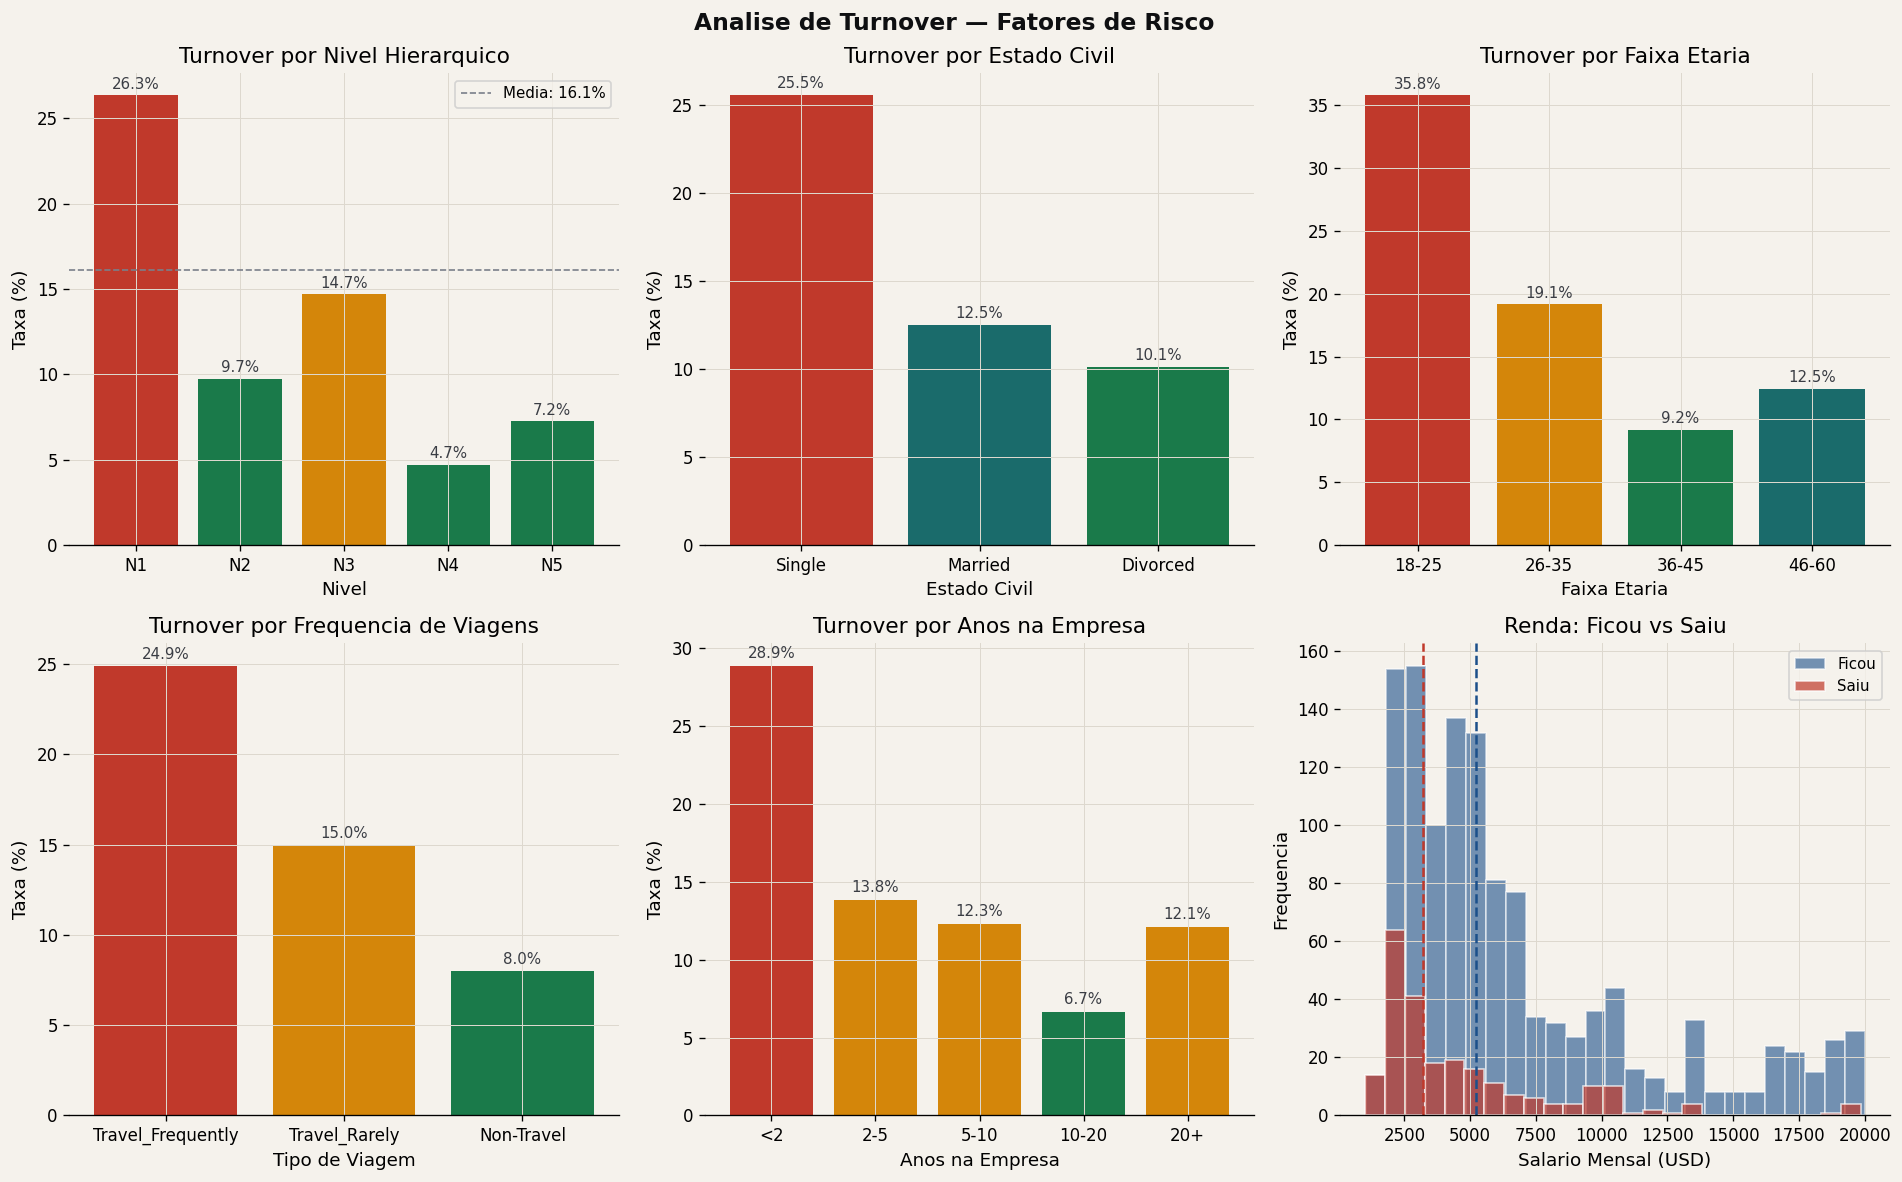

Insights:
  Turnover geral:         16.1%
  Com overtime:           30.5%
  Sem overtime:           10.4%
  Renda mediana (ficou):  $5,204
  Renda mediana (saiu):   $3,202


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor('#F5F2EC')
fig.suptitle('Analise de Turnover — Fatores de Risco', fontsize=14,
             fontweight='bold', color=C['ink'])

# 1. Por nivel hierarquico
ax = axes[0,0]
att_lv = df.groupby('JobLevel')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
lv_c = [C['red'] if v>20 else C['amber'] if v>12 else C['green'] for v in att_lv.values]
bars = ax.bar([f'N{l}' for l in att_lv.index], att_lv.values, color=lv_c)
ax.axhline(df['Attrition'].eq('Yes').mean()*100, color=C['ink3'],
           linestyle='--', linewidth=1, label=f'Media: {df["Attrition"].eq("Yes").mean()*100:.1f}%')
ax.set_title('Turnover por Nivel Hierarquico')
ax.set_xlabel('Nivel'); ax.set_ylabel('Taxa (%)')
ax.legend(fontsize=9)
for i, val in enumerate(att_lv.values):
    ax.text(i, val+0.4, f'{val:.1f}%', ha='center', fontsize=9, color=C['ink2'])

# 2. Por estado civil
ax = axes[0,1]
att_m = df.groupby('MaritalStatus')['Attrition'].apply(
    lambda x: (x=='Yes').mean()*100).sort_values(ascending=False)
ax.bar(att_m.index, att_m.values,
       color=[C['red'], C['teal'], C['green']])
ax.set_title('Turnover por Estado Civil')
ax.set_xlabel('Estado Civil'); ax.set_ylabel('Taxa (%)')
for i, val in enumerate(att_m.values):
    ax.text(i, val+0.4, f'{val:.1f}%', ha='center', fontsize=9, color=C['ink2'])

# 3. Por faixa etaria
ax = axes[0,2]
age_b = pd.cut(df['Age'], bins=[17,25,35,45,60], labels=['18-25','26-35','36-45','46-60'])
att_age = df.groupby(age_b)['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
ax.bar(att_age.index.astype(str), att_age.values,
       color=[C['red'],C['amber'],C['green'],C['teal']])
ax.set_title('Turnover por Faixa Etaria')
ax.set_xlabel('Faixa Etaria'); ax.set_ylabel('Taxa (%)')
for i, val in enumerate(att_age.values):
    ax.text(i, val+0.5, f'{val:.1f}%', ha='center', fontsize=9, color=C['ink2'])

# 4. Por business travel
ax = axes[1,0]
att_bt = df.groupby('BusinessTravel')['Attrition'].apply(
    lambda x: (x=='Yes').mean()*100).sort_values(ascending=False)
bt_c = [C['red'] if v>20 else C['amber'] if v>12 else C['green'] for v in att_bt.values]
ax.bar(att_bt.index, att_bt.values, color=bt_c)
ax.set_title('Turnover por Frequencia de Viagens')
ax.set_xlabel('Tipo de Viagem'); ax.set_ylabel('Taxa (%)')
for i, val in enumerate(att_bt.values):
    ax.text(i, val+0.4, f'{val:.1f}%', ha='center', fontsize=9, color=C['ink2'])

# 5. Por anos na empresa (agrupado)
ax = axes[1,1]
yrs_b = pd.cut(df['YearsAtCompany'], bins=[0,2,5,10,20,40],
               labels=['<2','2-5','5-10','10-20','20+'])
att_yrs = df.groupby(yrs_b)['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
yrs_c = [C['red'] if v>20 else C['amber'] if v>12 else C['green'] for v in att_yrs.values]
ax.bar(att_yrs.index.astype(str), att_yrs.values, color=yrs_c)
ax.set_title('Turnover por Anos na Empresa')
ax.set_xlabel('Anos na Empresa'); ax.set_ylabel('Taxa (%)')
for i, val in enumerate(att_yrs.values):
    ax.text(i, val+0.5, f'{val:.1f}%', ha='center', fontsize=9, color=C['ink2'])

# 6. Renda mensal: ficou vs saiu
ax = axes[1,2]
no_att  = df[df['Attrition']=='No']['MonthlyIncome']
yes_att = df[df['Attrition']=='Yes']['MonthlyIncome']
ax.hist(no_att, bins=25, alpha=0.6, color=C['blue'], label='Ficou', edgecolor='white')
ax.hist(yes_att, bins=25, alpha=0.7, color=C['red'], label='Saiu', edgecolor='white')
ax.axvline(no_att.median(), color=C['blue'], linestyle='--', linewidth=1.5)
ax.axvline(yes_att.median(), color=C['red'], linestyle='--', linewidth=1.5)
ax.set_title('Renda: Ficou vs Saiu')
ax.set_xlabel('Salario Mensal (USD)'); ax.set_ylabel('Frequencia')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('02_turnover_analysis.png', dpi=150, bbox_inches='tight', facecolor='#F5F2EC')
plt.show()

print("Insights:")
print(f"  Turnover geral:         {df['Attrition'].eq('Yes').mean()*100:.1f}%")
print(f"  Com overtime:           {(df[df['OverTime']=='Yes']['Attrition']=='Yes').mean()*100:.1f}%")
print(f"  Sem overtime:           {(df[df['OverTime']=='No']['Attrition']=='Yes').mean()*100:.1f}%")
print(f"  Renda mediana (ficou):  ${no_att.median():,.0f}")
print(f"  Renda mediana (saiu):   ${yes_att.median():,.0f}")


## 4. Performance e Engajamento

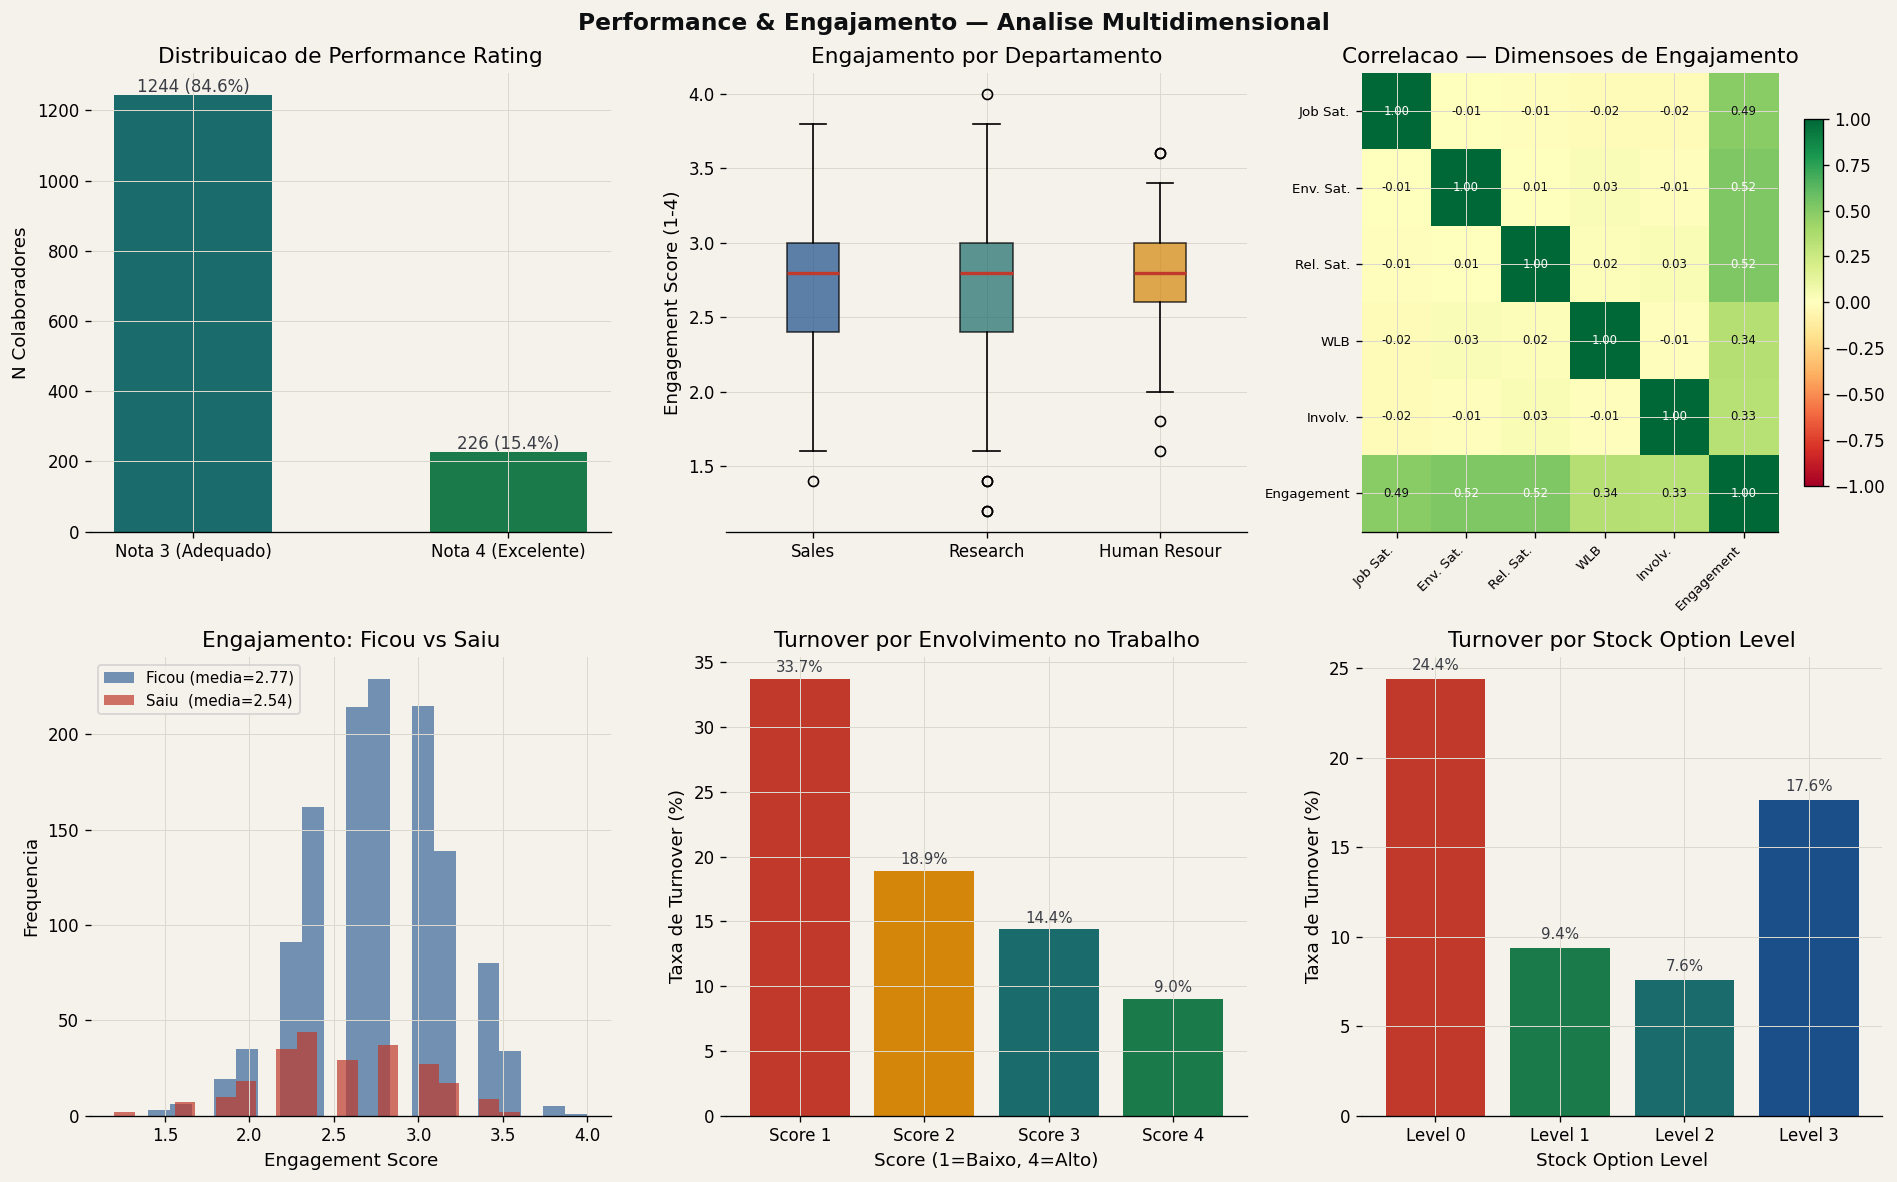

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor('#F5F2EC')
fig.suptitle('Performance & Engajamento — Analise Multidimensional',
             fontsize=14, fontweight='bold', color=C['ink'])

# 1. Performance Rating
ax = axes[0,0]
pc = df['PerformanceRating'].value_counts().sort_index()
ax.bar(['Nota 3 (Adequado)','Nota 4 (Excelente)'], pc.values,
       color=[C['teal'],C['green']], width=0.5)
ax.set_title('Distribuicao de Performance Rating')
ax.set_ylabel('N Colaboradores')
for i, val in enumerate(pc.values):
    ax.text(i, val+8, f'{val} ({val/len(df)*100:.1f}%)',
            ha='center', fontsize=10, color=C['ink2'])

# 2. Engajamento por departamento (boxplot)
ax = axes[0,1]
depts = df['Department'].unique()
data_box = [df[df['Department']==d]['EngagementScore'].values for d in depts]
bp = ax.boxplot(data_box, labels=[d.split('&')[0].strip()[:12] for d in depts],
                patch_artist=True,
                medianprops={'color': C['red'], 'linewidth': 2})
for patch, c in zip(bp['boxes'], [C['blue'],C['teal'],C['amber']]):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_title('Engajamento por Departamento')
ax.set_ylabel('Engagement Score (1-4)')

# 3. Heatmap correlacoes
ax = axes[0,2]
corr_cols = ['JobSatisfaction','EnvironmentSatisfaction','RelationshipSatisfaction',
             'WorkLifeBalance','JobInvolvement','EngagementScore']
corr_lbl  = ['Job Sat.','Env. Sat.','Rel. Sat.','WLB','Involv.','Engagement']
cm_data   = df[corr_cols].corr()
im = ax.imshow(cm_data.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr_lbl))); ax.set_yticks(range(len(corr_lbl)))
ax.set_xticklabels(corr_lbl, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr_lbl, fontsize=8)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{cm_data.values[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='white' if abs(cm_data.values[i,j])>0.5 else C['ink'])
ax.set_title('Correlacao — Dimensoes de Engajamento')
plt.colorbar(im, ax=ax, shrink=0.8)

# 4. Engajamento vs Attrition
ax = axes[1,0]
eng_no  = df[df['Attrition']=='No']['EngagementScore']
eng_yes = df[df['Attrition']=='Yes']['EngagementScore']
ax.hist(eng_no,  bins=20, alpha=0.6, color=C['blue'], label=f'Ficou (media={eng_no.mean():.2f})')
ax.hist(eng_yes, bins=20, alpha=0.7, color=C['red'],  label=f'Saiu  (media={eng_yes.mean():.2f})')
ax.set_title('Engajamento: Ficou vs Saiu')
ax.set_xlabel('Engagement Score'); ax.set_ylabel('Frequencia')
ax.legend(fontsize=9)

# 5. Job Involvement vs Turnover
ax = axes[1,1]
inv_att = df.groupby('JobInvolvement')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
ax.bar([f'Score {s}' for s in inv_att.index], inv_att.values,
       color=[C['red'],C['amber'],C['teal'],C['green']])
ax.set_title('Turnover por Envolvimento no Trabalho')
ax.set_xlabel('Score (1=Baixo, 4=Alto)'); ax.set_ylabel('Taxa de Turnover (%)')
for i, val in enumerate(inv_att.values):
    ax.text(i, val+0.5, f'{val:.1f}%', ha='center', fontsize=9, color=C['ink2'])

# 6. Stock Options vs Turnover
ax = axes[1,2]
so_att = df.groupby('StockOptionLevel')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
ax.bar([f'Level {s}' for s in so_att.index], so_att.values,
       color=[C['red'],C['green'],C['teal'],C['blue']])
ax.set_title('Turnover por Stock Option Level')
ax.set_xlabel('Stock Option Level'); ax.set_ylabel('Taxa de Turnover (%)')
for i, val in enumerate(so_att.values):
    ax.text(i, val+0.5, f'{val:.1f}%', ha='center', fontsize=9, color=C['ink2'])

plt.tight_layout()
plt.savefig('03_performance_engagement.png', dpi=150, bbox_inches='tight', facecolor='#F5F2EC')
plt.show()


## 5. Modelo Preditivo XGBoost

In [8]:
# Pre-processamento
cat_cols = ['BusinessTravel','Department','EducationField',
            'Gender','JobRole','MaritalStatus','OverTime']
df_ml = df.copy()
le = LabelEncoder()
for c in cat_cols:
    df_ml[c] = le.fit_transform(df_ml[c])

df_ml['Attrition_bin'] = (df_ml['Attrition']=='Yes').astype(int)
features = [c for c in df_ml.columns if c not in ['Attrition','Attrition_bin']]

X = df_ml[features]
y = df_ml['Attrition_bin']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
print(f"Turnover no treino: {y_train.mean()*100:.1f}% | Teste: {y_test.mean()*100:.1f}%")


Treino: 1176 amostras | Teste: 294 amostras
Turnover no treino: 16.2% | Teste: 16.0%


In [9]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print("=" * 45)
print("       RESULTADOS DO MODELO XGBOOST")
print("=" * 45)
print(f"  ROC-AUC:  {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Fica','Sai']))


       RESULTADOS DO MODELO XGBOOST
  ROC-AUC:  0.784

              precision    recall  f1-score   support

        Fica       0.88      0.98      0.93       247
         Sai       0.72      0.28      0.40        47

    accuracy                           0.87       294
   macro avg       0.80      0.63      0.66       294
weighted avg       0.85      0.87      0.84       294



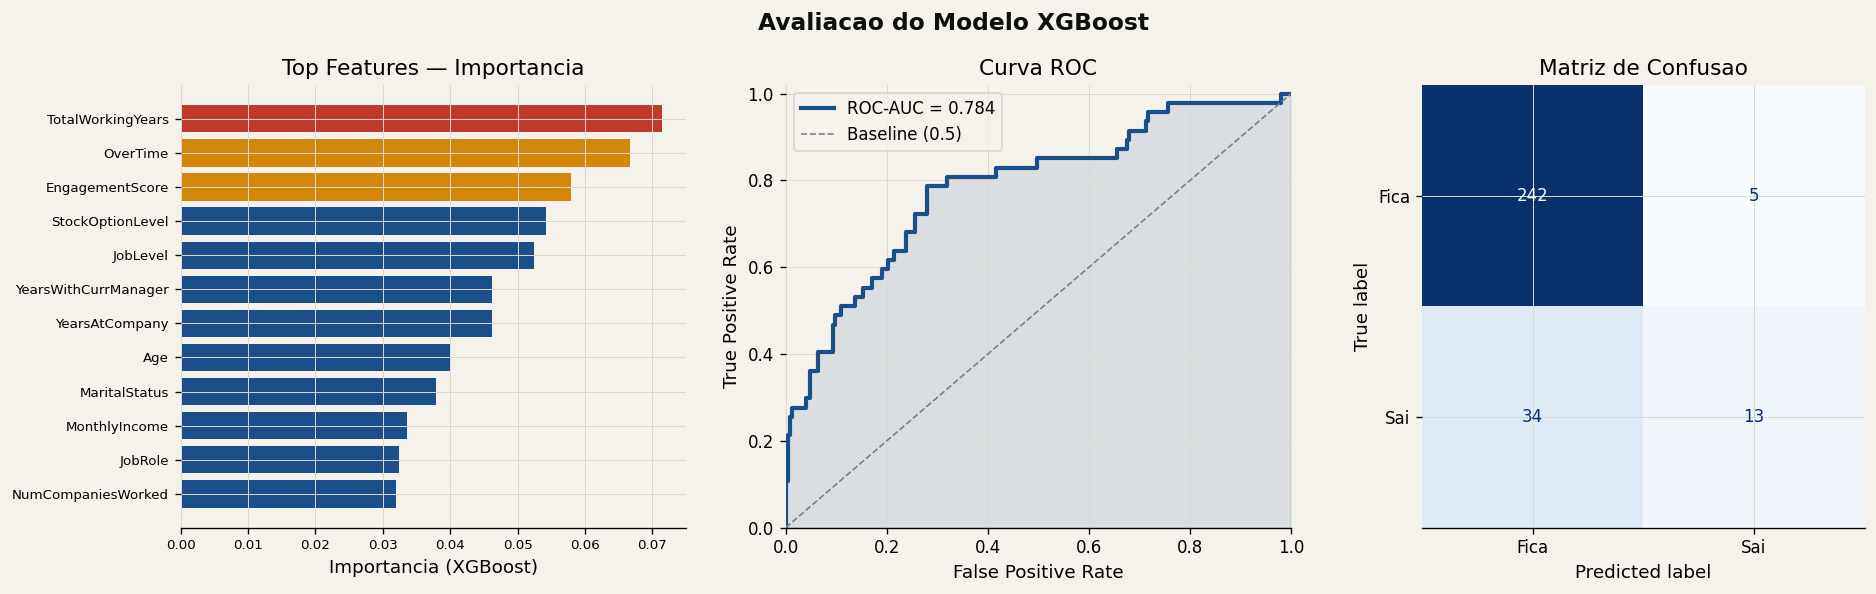

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#F5F2EC')
fig.suptitle('Avaliacao do Modelo XGBoost', fontsize=14,
             fontweight='bold', color=C['ink'])

# 1. Feature Importance
ax = axes[0]
imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True).tail(12)
imp_c = [C['red'] if i==imp.index[-1] else
         C['amber'] if i in list(imp.index[-3:]) else C['blue']
         for i in imp.index]
ax.barh(imp.index, imp.values, color=imp_c)
ax.set_title('Top Features — Importancia')
ax.set_xlabel('Importancia (XGBoost)')
ax.tick_params(labelsize=8)

# 2. Curva ROC
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_val = auc(fpr, tpr)
ax.plot(fpr, tpr, color=C['blue'], linewidth=2.5, label=f'ROC-AUC = {roc_val:.3f}')
ax.plot([0,1],[0,1], color=C['ink3'], linestyle='--', linewidth=1, label='Baseline (0.5)')
ax.fill_between(fpr, tpr, alpha=0.12, color=C['blue'])
ax.set_title('Curva ROC')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=10)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

# 3. Matriz de Confusao
ax = axes[2]
cm_val = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=['Fica','Sai'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusao')

plt.tight_layout()
plt.savefig('04_model_evaluation.png', dpi=150, bbox_inches='tight', facecolor='#F5F2EC')
plt.show()


## 6. Validacao Cruzada e Score de Risco

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')

print("Cross-Validation 5-Fold (ROC-AUC):")
for i, s in enumerate(cv_scores, 1):
    bar = '#' * int(s * 40)
    print(f"  Fold {i}: {s:.3f}  {bar}")
print(f"  Media:  {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")


Cross-Validation 5-Fold (ROC-AUC):
  Fold 1: 0.806  ################################
  Fold 2: 0.840  #################################
  Fold 3: 0.854  ##################################
  Fold 4: 0.827  #################################
  Fold 5: 0.813  ################################
  Media:  0.828 +/- 0.017


In [14]:
# Gerar score de risco para todos os colaboradores
df['RiskScore'] = model.predict_proba(X)[:,1]
df['RiskLabel'] = pd.cut(df['RiskScore'],
                          bins=[0, 0.25, 0.50, 1.0],
                          labels=['Baixo','Medio','Alto'])

print("Distribuicao de Risco de Turnover:")
print(df['RiskLabel'].value_counts())
print()

high = df[df['RiskLabel']=='Alto']
print(f"Perfil dos colaboradores de ALTO RISCO ({len(high)} pessoas):")
print(f"  % com overtime:          {(high['OverTime']=='Yes').mean()*100:.1f}%")
print(f"  Nivel hierarquico medio: {high['JobLevel'].mean():.1f}")
print(f"  Satisfacao media:        {high['JobSatisfaction'].mean():.1f}/4")
print(f"  Engajamento medio:       {high['EngagementScore'].mean():.2f}/4")
print(f"  Anos na empresa (media): {high['YearsAtCompany'].mean():.1f}")
print(f"  Salario medio:           ${high['MonthlyIncome'].mean():,.0f}")
print(f"  % solteiros:             {(high['MaritalStatus']=='Single').mean()*100:.1f}%")


Distribuicao de Risco de Turnover:
RiskLabel
Baixo    1224
Alto      184
Medio      62
Name: count, dtype: int64

Perfil dos colaboradores de ALTO RISCO (184 pessoas):
  % com overtime:          57.6%
  Nivel hierarquico medio: 1.6
  Satisfacao media:        2.4/4
  Engajamento medio:       2.49/4
  Anos na empresa (media): 4.2
  Salario medio:           $4,505
  % solteiros:             53.3%


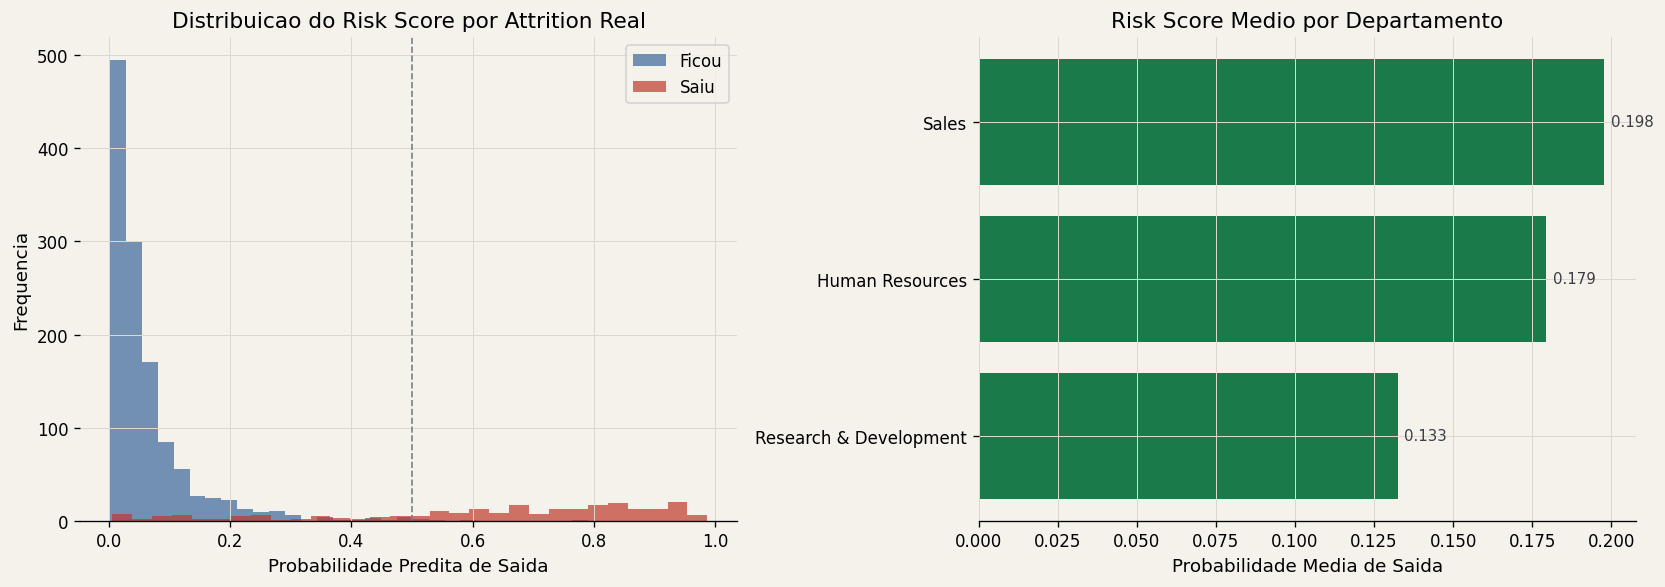

In [15]:
# Visualizacao do score de risco
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#F5F2EC')

# Distribuicao do risk score
ax = axes[0]
ax.hist(df[df['Attrition']=='No']['RiskScore'], bins=30,
        alpha=0.6, color=C['blue'], label='Ficou')
ax.hist(df[df['Attrition']=='Yes']['RiskScore'], bins=30,
        alpha=0.7, color=C['red'], label='Saiu')
ax.set_title('Distribuicao do Risk Score por Attrition Real')
ax.set_xlabel('Probabilidade Predita de Saida')
ax.set_ylabel('Frequencia')
ax.legend(fontsize=10)
ax.axvline(0.5, color=C['ink3'], linestyle='--', linewidth=1, label='Threshold 0.5')

# Risk score por departamento
ax = axes[1]
risk_dept = df.groupby('Department')['RiskScore'].mean().sort_values(ascending=True)
ax.barh(risk_dept.index, risk_dept.values,
        color=[C['green'] if v<0.2 else C['amber'] if v<0.25 else C['red']
               for v in risk_dept.values])
ax.set_title('Risk Score Medio por Departamento')
ax.set_xlabel('Probabilidade Media de Saida')
for i, (idx, val) in enumerate(risk_dept.items()):
    ax.text(val+0.002, i, f'{val:.3f}', va='center', fontsize=9, color=C['ink2'])

plt.tight_layout()
plt.savefig('05_risk_score.png', dpi=150, bbox_inches='tight', facecolor='#F5F2EC')
plt.show()


## 7. Conclusoes e Recomendacoes

### Turnover (16,1% — 237 colaboradores)
- **Overtime** e o fator mais controlavel: 30,5% vs 10,4% — quase 3x mais risco
- **Nivel 1 (junior)** tem 26,3% de turnover — 5x maior que o nivel 4 (4,7%)
- **Solteiros (25,5%)** e jovens de 18-25 (35,8%) sao os perfis mais vulneraveis
- Colaboradores com **viagens frequentes** tem 2x mais turnover que os que nao viajam

### Performance & Engajamento
- Apenas **15,4%** atingem performance maxima — espaco para desenvolvimento
- **39%** dos colaboradores tem satisfacao baixa ou regular (scores 1-2)
- Colaboradores que sairam tem engajamento medio **0,3 pontos menor** que os que ficaram
- **Stock options** tem correlacao inversa forte com turnover: level 0 = 24%, level 1 = 11%

### Modelo XGBoost
- **ROC-AUC: 0,784** — resultado solido, muito acima do baseline de 0,5
- Top preditores: TotalWorkingYears, OverTime, EngagementScore, StockOptionLevel, JobLevel
- Pode ser integrado ao HRIS para score mensal de risco por colaborador

### Recomendacoes
1. **Revisar politica de overtime** — maior impacto imediato na retencao
2. **Plano de carreira para juniores** — reduzir turnover do nivel 1
3. **Expandir programa de stock options** — retencao de talentos de longo prazo
4. **Pesquisa de clima trimestral** — monitorar os 5 pilares de engajamento
5. **Deploy do modelo preditivo** — triagem mensal de colaboradores em risco

---
> **Fonte:** IBM HR Analytics Employee Attrition & Performance  
> **Kaggle:** https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset  
> **Dataset:** 1.470 colaboradores reais, 31 variaveis
